In [1]:
import os
os.chdir('..')

In [2]:
import json
import numpy as np
import torch
from tqdm.auto import tqdm
from PIL import Image
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image
from IPython.display import display
import torch.nn.functional as F

from modeling import get_model
from diffusion.scheduler import get_scheduler
from diffusion.sampler import get_sampler
from utils import count_parameters

In [3]:
device = torch.device('cuda:0')
device

device(type='cuda', index=0)

In [4]:
def tensor2image(tensor, value_range=(-1, 1), resize_factor=None):
    if value_range is not None:
        tensor = (tensor - value_range[0]) / (value_range[1] - value_range[0])
    tensor = tensor.clamp(0, 1)
    image = to_pil_image(tensor)
    if resize_factor is not None:
        new_size = (int(image.width * resize_factor), int(image.height * resize_factor))
        image = image.resize(new_size, resample=Image.NEAREST)
    return image

In [5]:
def load_singlecls_ckpt(ckpt_dir, ema=True, device='cpu'):
    with open(os.path.join(ckpt_dir, 'train_args.json'), 'r') as f:
        train_args = json.load(f)

    model = get_model(train_args['model_type'], **train_args['model_cfg'])
    ckpt_name = os.listdir(os.path.join(ckpt_dir, 'ckpts'))
    assert len(ckpt_name) == 1
    ckpt_name = ckpt_name[0]
    ckpt_path = os.path.join(
        ckpt_dir, 'ckpts', ckpt_name, 
        'ema_model.pt' if ema else 'model.pt'
    )
    print(f'loading ckpt "{ckpt_path}"')
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device)

    scheduler = get_scheduler(train_args['scheduler_type'], **train_args['scheduler_cfg'])
    sampler = get_sampler(train_args['sampler_type'], **train_args['sampler_cfg'])

    return model, scheduler, sampler

In [6]:
# image_save_dir = 'resources/ppt_image'
# os.makedirs(image_save_dir, exist_ok=True)

In [7]:
dataset_type = 'mnist'
if dataset_type == 'mnist':
    image_shape = (1, 28, 28)
elif dataset_type == 'cifar10':
    image_shape = (3, 32, 32)
else:
    raise ValueError(f"Unknown dataset type: {dataset_type}")

In [8]:
from diffusion.sampler import BaseSampler

class CustomDDIMSampler(BaseSampler):
    def __init__(self, n_steps, clip_latent=True, pbar=False, pbar_kwargs=None):
        super().__init__(n_steps, pbar, pbar_kwargs)
        self.clip_latent = clip_latent
    
    @torch.no_grad()
    def sample(
            self, 
            z: torch.Tensor, scheduler, pred_fn, 
            initial_timestep=None,
            gen=None
    ):

        t_steps = torch.linspace(
            scheduler.n_steps - 1, 0,
            steps=self.n_steps + 1,
            dtype=torch.int64,
            device=z.device
        )[:-1]
        if initial_timestep is not None:
            assert (t_steps == initial_timestep).any().item(), "initial_timestep must be in t_steps"
            idx = (t_steps == initial_timestep).nonzero(as_tuple=True)[0].item()
            t_steps = t_steps[idx:]

        iterator = self.prepare_iterator(range(len(t_steps)))
        for i in iterator:
            eps_pred = pred_fn(z, t_steps[i].repeat(z.size(0)))
            t = scheduler.get_schedule(t_steps[i])

            alpha_t_ = t.alpha.to(z.dtype)
            sigma_t_ = t.sigma.to(z.dtype)
            x0_pred = (z - sigma_t_ * eps_pred) / alpha_t_
            if self.clip_latent:
                x0_pred = torch.clip(x0_pred, -1, 1)

            if i < len(t_steps) - 1:
                t_prime = scheduler.get_schedule(t_steps[i + 1])

                alpha_t_prime_ = t_prime.alpha.to(z.dtype)
                sigma_t_prime_ = t_prime.sigma.to(z.dtype)
                z = alpha_t_prime_ * x0_pred + sigma_t_prime_ * eps_pred

            else:
                z = x0_pred

        return z
class CustomDDPMSampler(BaseSampler):
    @torch.no_grad()
    def sample(
            self,
            z: torch.Tensor,
            scheduler,
            pred_fn,
            initial_timestep=None,
            gen=None,
    ):
        t_steps = torch.linspace(
            scheduler.n_steps - 1, 0,
            steps=self.n_steps + 1,
            dtype=torch.int64,
            device=z.device
        )[:-1]
        if initial_timestep is not None:
            assert (t_steps == initial_timestep).any().item(), "initial_timestep must be in t_steps"
            idx = (t_steps == initial_timestep).nonzero(as_tuple=True)[0].item()
            t_steps = t_steps[idx:]

        schedule = scheduler.get_schedule(t_steps)
        beta = scheduler.beta.to(device=z.device, dtype=z.dtype)[t_steps]
        coef = beta / schedule.sigma.to(device=z.device, dtype=z.dtype)
        inv_alpha_sqrt = 1 / torch.sqrt(1 - beta)
        sigma = torch.sqrt(beta)

        iterator = self.prepare_iterator(range(len(t_steps)))
        for i in iterator:
            eps_pred = pred_fn(z, t_steps[i].repeat(z.size(0)))
            z = inv_alpha_sqrt[i] * (z - coef[i] * eps_pred)
            
            if i < len(t_steps) - 1:
                noise = torch.randn_like(z, generator=gen)
                z = z + sigma[i] * noise

        return z

In [9]:
image_save_dir = 'resources/ppt_image_sdeedit'
save_image = True
if save_image:
    os.makedirs(image_save_dir, exist_ok=True)

In [10]:
sampler = CustomDDIMSampler(n_steps=1000, pbar=True, clip_latent=False)
# sampler = CustomDDPMSampler(n_steps=1000, pbar=True)
sampler_type = 'ddpm' if isinstance(sampler, CustomDDPMSampler) else 'ddim'

In [11]:
from torchvision.datasets import MNIST, CIFAR10
import torchvision.transforms as T
import torchvision.transforms.functional as TF

ds_class = MNIST if dataset_type == 'mnist' else CIFAR10
transform = T.Compose([T.ToTensor(), T.Normalize(0.5, 0.5)])
ds = ds_class('/home/jimyeong/datasets', download=True, transform=transform)
ds

Dataset MNIST
    Number of datapoints: 60000
    Root location: /home/jimyeong/datasets
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [12]:
models = []
for i in range(10):
    ckpt_dir = f'outputs/mnist_single/beta_cls{i}'
    model, scheduler, _ = load_singlecls_ckpt(ckpt_dir)
    model.eval()
    model.to(device)
    models.append(model)
count_parameters(model)

loading ckpt "outputs/mnist_single/beta_cls0/ckpts/ckpt-010500/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls1/ckpts/ckpt-020000/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls2/ckpts/ckpt-011000/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls3/ckpts/ckpt-010000/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls4/ckpts/ckpt-009500/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls5/ckpts/ckpt-009500/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls6/ckpts/ckpt-010500/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls7/ckpts/ckpt-013500/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls8/ckpts/ckpt-010000/ema_model.pt"
loading ckpt "outputs/mnist_single/beta_cls9/ckpts/ckpt-012500/ema_model.pt"


13716929

Label: 7


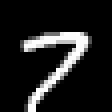

In [13]:
sample_idx = 123
sample_x, sample_y = ds[sample_idx]
print(f"Label: {sample_y}")
tensor2image(sample_x, resize_factor=4)

In [14]:
noise_seed = (sample_idx ** 2)%(2**32)
gen_seed = ((noise_seed-1)**2)%(2**32)
print(f'seed: {noise_seed}')
print(f'gen_seed: {gen_seed}')
noise = torch.randn_like(
    sample_x, 
    generator=torch.Generator(device=sample_x.device).manual_seed(noise_seed)
)
n_perturb_steps = 10
perturb_steps = torch.linspace(0, scheduler.n_steps-1, steps=n_perturb_steps+1, dtype=torch.int64)[1:]
perturb_steps

seed: 15129
gen_seed: 228856384


tensor([ 99, 199, 299, 399, 499, 599, 699, 799, 899, 999])

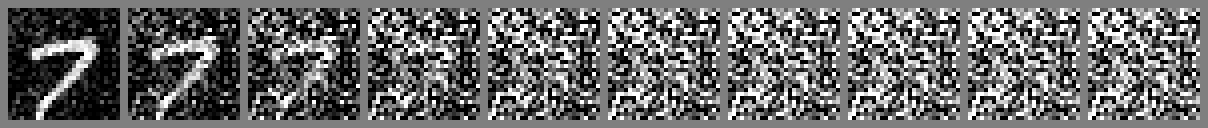

In [18]:
perturbed = sample_x.unsqueeze(0).repeat_interleave(n_perturb_steps, dim=0)
perturbed = scheduler.diffuse(perturbed, perturb_steps, noise)
tensor2image(make_grid(perturbed.cpu(), nrow=n_perturb_steps), resize_factor=4)

In [19]:
target_cls = 0
model = models[target_cls]
gen = torch.Generator(device=device).manual_seed(gen_seed)
pred_fn = model.get_pred_fn()
rets = []
for i, step in enumerate(perturb_steps):
    perturbed_x = perturbed[i].unsqueeze(0).to(device)
    with torch.no_grad():
        ret = sampler.sample(perturbed_x, scheduler, pred_fn, initial_timestep=step)
    rets.append(ret[0].cpu())
img = tensor2image(make_grid(rets, nrow=n_perturb_steps), resize_factor=4)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/700 [00:00<?, ?it/s]

  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

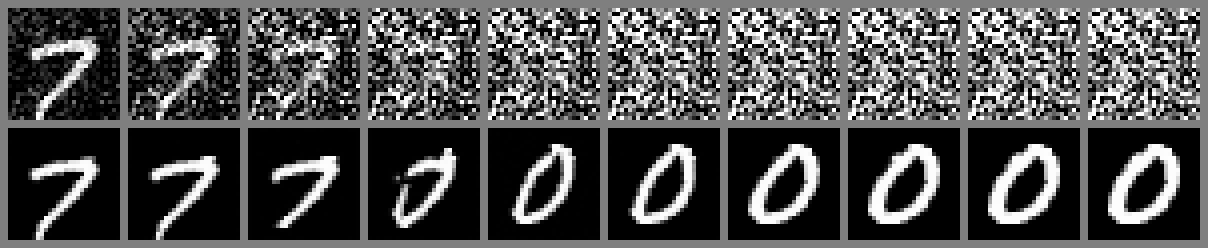

In [20]:
tmp = torch.cat([perturbed, torch.stack(rets, dim=0)], dim=0)
img = tensor2image(make_grid(tmp, nrow=n_perturb_steps), resize_factor=4)
display(img)
if save_image:
    img.save(os.path.join(image_save_dir, f'singlemodel_idx{sample_idx}_{sample_y}to{target_cls}_{sampler_type}{sampler.n_steps}.png'))

In [23]:
rets = []
for tcls in tqdm(range(10)):
    model = models[tcls]
    gen = torch.Generator(device=device).manual_seed(gen_seed)
    pred_fn = model.get_pred_fn()
    for i, step in enumerate(perturb_steps):
        perturbed_x = perturbed[i].unsqueeze(0).to(device)
        with torch.no_grad():
            ret = sampler.sample(perturbed_x, scheduler, pred_fn, initial_timestep=step)
        rets.append(ret[0].cpu())

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/70 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

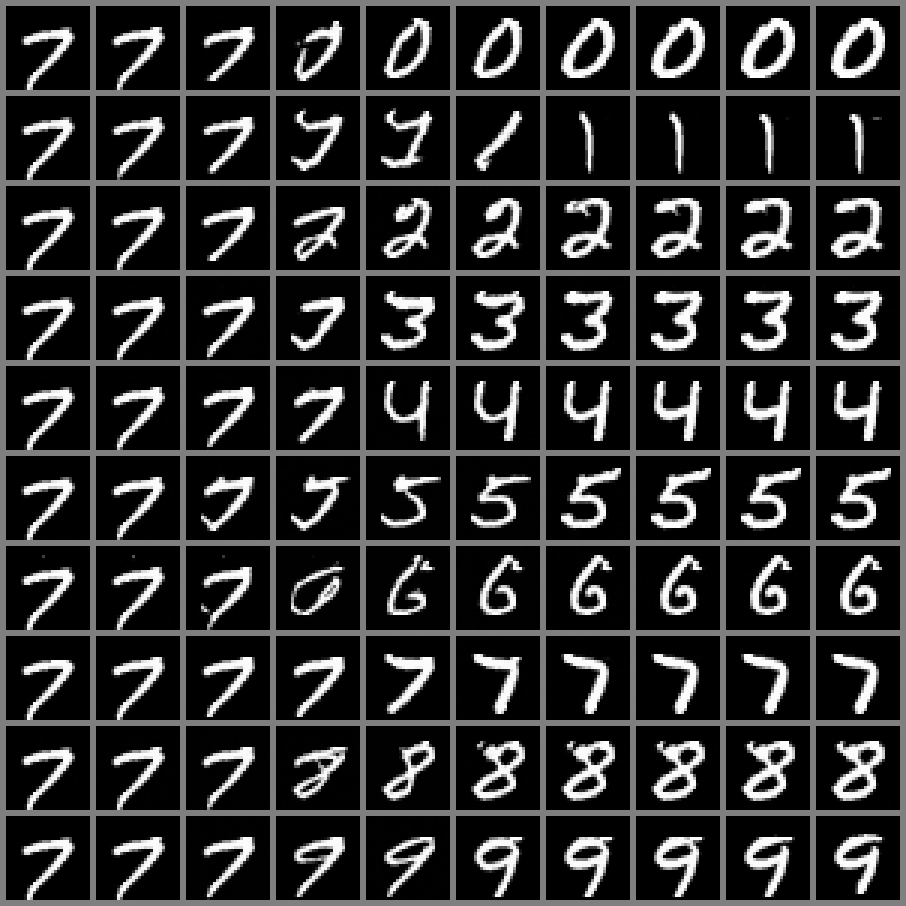

In [25]:
img = tensor2image(make_grid(rets, nrow=n_perturb_steps), resize_factor=3)
display(img)

Label: 7
seed: 15129
gen_seed: 228856384


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

...

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/700 [00:00<?, ?it/s]

  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

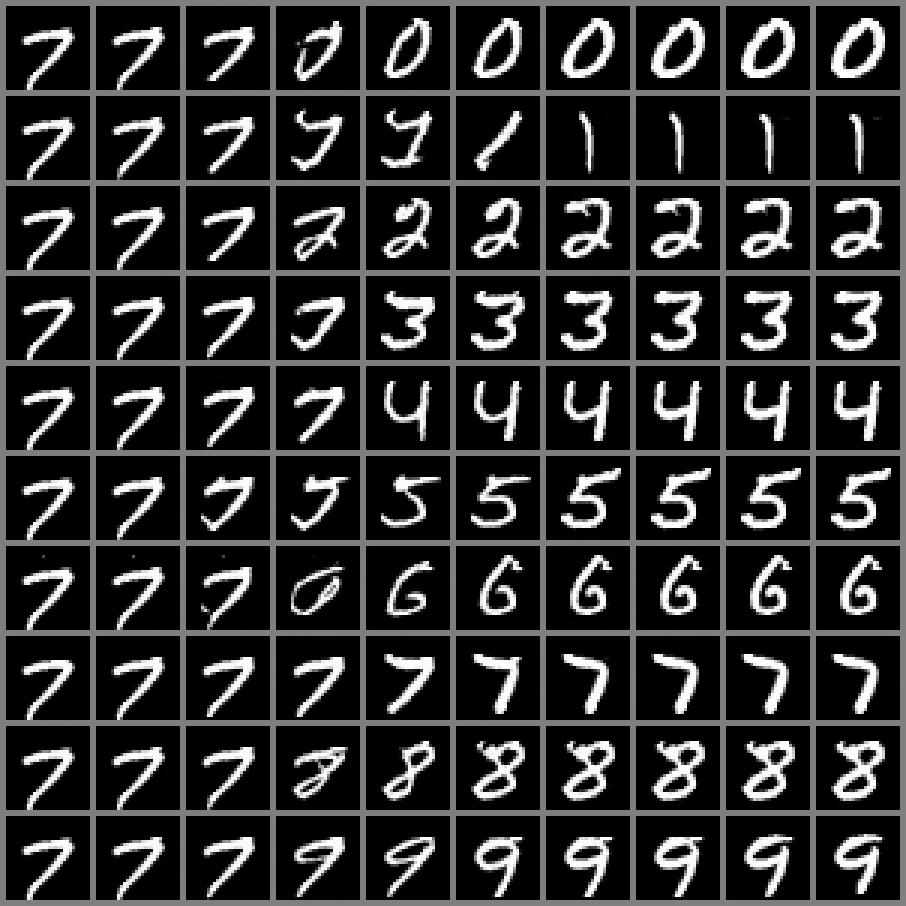

Label: 3
seed: 1522756
gen_seed: 3795417481


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

...

  0%|          | 0/700 [00:00<?, ?it/s]

  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [15]:
for sample_idx in (123, 1234, 54321):
    sample_x, sample_y = ds[sample_idx]
    print(f"Label: {sample_y}")

    noise_seed = (sample_idx ** 2)%(2**32)
    gen_seed = ((noise_seed-1)**2)%(2**32)
    print(f'seed: {noise_seed}')
    print(f'gen_seed: {gen_seed}')

    noise = torch.randn_like(
        sample_x, 
        generator=torch.Generator(device=sample_x.device).manual_seed(noise_seed)
    )

    n_perturb_steps = 10
    perturb_steps = torch.linspace(0, scheduler.n_steps-1, steps=n_perturb_steps+1, dtype=torch.int64)[1:]

    perturbed = sample_x.unsqueeze(0).repeat_interleave(n_perturb_steps, dim=0)
    perturbed = scheduler.diffuse(perturbed, perturb_steps, noise)

    rets = []
    for tcls in tqdm(range(10)):
        model = models[tcls]
        gen = torch.Generator(device=device).manual_seed(gen_seed)
        pred_fn = model.get_pred_fn()
        for i, step in enumerate(perturb_steps):
            perturbed_x = perturbed[i].unsqueeze(0).to(device)
            with torch.no_grad():
                ret = sampler.sample(perturbed_x, scheduler, pred_fn, initial_timestep=step)
            rets.append(ret[0].cpu())
    img = tensor2image(make_grid(rets, nrow=n_perturb_steps), resize_factor=3)
    display(img)
    if save_image:
        img.save(os.path.join(image_save_dir, f'singlemodel_idx{sample_idx}_all_{sampler_type}{sampler.n_steps}.png'))